# Homework 3: Logistic Regression
**Name:** Nicholas Starace  
**Student ID:** 4556822  
**D Value:** 22  

## Question 1: Building a Logistic Regression Classifier 

### Part A: Data Preparation

In [1]:
import numpy as np
import matplotlib.pyplot as plt
D = 22.0

# Load Exam Data from txt File
data = np.loadtxt('input/hw3_data1.txt', delimiter=',')
Xnb = np.array(data[:, 0:2])
y = np.array(data[:, 2])
numSamples = Xnb.shape[0]

# Add Bias Term to X
biasArr = np.ones([numSamples])
X = np.zeros([numSamples, 3])
X[:, 0] = biasArr               # Bias Arr n x 1                                      
X[:, 1:3] = Xnb                 # Xnb is n x 2

print(X.shape)
print(y.shape)

(100, 3)
(100,)


**Text Response:** The dimensions of X are (100, 3) and y is (100, 1)

### Part B: Data Visualization

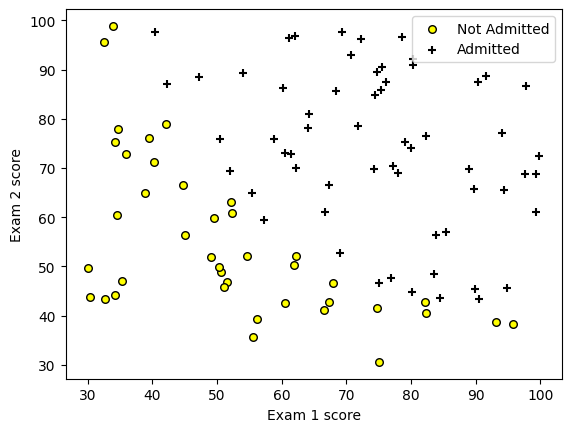

In [2]:
# Split X 
XnotAdmit = X[y==0, :] # Construct not admitted
XAdmit = X[y == 1, :] # Construct admitted

plt.scatter(XnotAdmit[:,1], XnotAdmit[:,2], s=30, marker="o", color="yellow", edgecolors="black", label="Not Admitted")
plt.scatter(XAdmit[:,1], XAdmit[:,2], marker="+", color="black", label="Admitted")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.legend(loc="upper right")


### Part C: Train/Test Split

In [3]:
# Randomly split data
seedD = int(D)
np.random.seed(seedD)
randArr = np.random.permutation(numSamples)
randArrTrain = randArr[0:90]                # 90% of Samples used to Train
randArrTest = randArr[90:100]               # 10% of Samples used to Test
X_train = X[randArrTrain, :]                # Take only first 90 samples of random index
X_test = X[randArrTest, :]                  # Take only last 10 samples of random index
y_train = y[randArrTrain]
y_test = y[randArrTest]

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(90, 3)
(10, 3)
(90,)
(10,)


**Text Response:** Training set contains 90 samples. Testing set contains 10 samples.

### Part D: Sigmoid Function

Text(0, 0.5, 'g(z)')

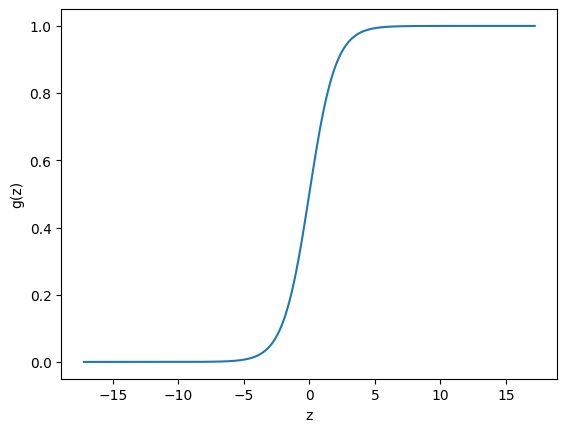

In [4]:
def sigmoid(z):
    g = 1 / (1 + np.exp(-z))                
    return g

maxz = D/10
maxz = 15 + maxz
minz = -maxz
numsampZ = int((maxz - minz) / 0.01)        # Num Samples = range / deltaZ
z = np.linspace(minz, maxz, num=numsampZ)
g = sigmoid(z)

plt.plot(z, g)
plt.xlabel("z")
plt.ylabel("g(z)")

**Text Response:** g(z) = 0.1 at z = -2.2. g(z) exceeds 0.9 at z = 2.2.

### Part E: Cost Function and Gradient

In [5]:
# Cost Function
def costFunction(theta, X, y):
    m = y.shape[0]

    # Compute Hypothesis using Sigmoid
    z = X @ theta
    h = sigmoid(z)
    
    # Compute Cost
    tm1 = y * np.log(h)                 # Cost when y = 1
    tm2 = (1 - y) * np.log(1 - h)       # Cost when y = 0
    inner = tm1 + tm2                   # y *, (1-y) force terms to drop out when y ~= applicable term
    J = np.sum(inner) * (-1 / m)
    return J

In [6]:
def gradFunction(theta, X, y):
    m = y.shape[0]

    # Compute Hypothess
    h = sigmoid(X @ theta)      # m sample vector

    # Compute Gradient
    grad = (1/m) * (X.T @ (h - y))  # vector with n samples, XT[n x m]], h[m x 1]

    return grad


In [7]:
# Declare Toy Dataset
X = np.array([[1, 1, 0], [1, 1, 3], [1, 3, 1], [1, 3, 4]])  # Include bias feature
y = np.array([0, 1, 0, 1])                                  # Delcare as vector so that 1 x m or m x 1    
theta = np.array([1 + float(D/100), 0.9, 1.2])     

# Compute Cost
J = costFunction(theta, X, y)
print(J)

1.8406881950464733


**Text Output:** Cost for Toy Dataset = 1.84

### Part F: Training with Optimization

In [8]:
from scipy.optimize import minimize
# Initialize theta to 0
initial_theta = np.array([0, 0, 0])  

result = minimize(fun=costFunction, x0=initial_theta, args=(X_train, y_train), 
                  method='BFGS', jac=gradFunction, options={'maxiter': 400,})
 
theta_opt = result.x
print(theta_opt)


[-24.0336669    0.19661962   0.19394104]


C:\Users\nstar\AppData\Local\Temp\ipykernel_50264\3226032841.py:11: RuntimeWarning: divide by zero encountered in log
  tm2 = (1 - y) * np.log(1 - h)       # Cost when y = 0
C:\Users\nstar\AppData\Local\Temp\ipykernel_50264\3226032841.py:11: RuntimeWarning: invalid value encountered in multiply
  tm2 = (1 - y) * np.log(1 - h)       # Cost when y = 0


**Text Output:** Optimal Theta = (-24.03, 0.1966, 0.1939)

### Part G: Decision Boundary Visualzation

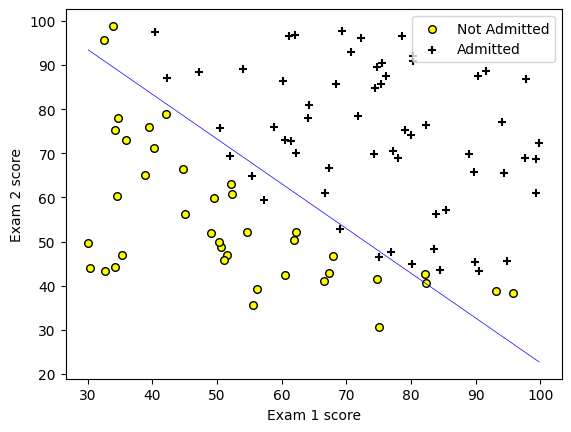

In [9]:
# Solve for X2 Decision Boundary
# th0 + th1*x1 + th2*x2 = 0
# --> x2 = -(th0 + th1x1) / th2
X1line = np.linspace(start=X_train[:, 1].min(), stop=X_train[:, 1].max(), num=200)     # Since X_train is random, find min and max to fit lne
X2line = -(theta_opt[0] + (theta_opt[1] * X1line)) / theta_opt[2]       

# Reconstruct scatter plot with boundary line
plt.plot(X1line, X2line, color="blue", linewidth=0.5)
plt.scatter(XnotAdmit[:,1], XnotAdmit[:,2], s=30, marker="o", color="yellow", edgecolors="black", label="Not Admitted")
plt.scatter(XAdmit[:,1], XAdmit[:,2], marker="+", color="black", label="Admitted")
plt.xlabel("Exam 1 score")
plt.ylabel("Exam 2 score")
plt.legend(loc="upper right")


### Part H: Model Evaluation

In [10]:
# Calculate Hypothesis from Testing Set and Optimal Theta
Est = X_test @ theta_opt

# Find Probability of Hypothesis using signois func
Pr = sigmoid(Est)

# Classify based on Pr < 0.5 = not admitted, Pr >= 0.5 = admitted
yExpAdmit = Pr[Pr >= 0.5]
yExpNotAdmit = Pr[Pr < 0.5]

# Construct expected output
yExpect = Est               # Start with copy of estimate output
yExpect[Pr >= 0.5] = 1      # If probability is greater or equal to 0.5, set index to admitted
yExpect[Pr < 0.5] = 0       # If probability is less than 0.5, set index to not admitted

# Evaluate Accuracy
numCorrectVec = Est
numCorrectVec[yExpect == y_test] = 1
numCorrectVec[yExpect != y_test] = 0
numCorrect = numCorrectVec.sum()
Accuracy = numCorrect / y_test.shape * 100
print(Accuracy)


[60.]


**Text Output:** 60% of Samples Classified Correctly in Admissions Statistics

### Part I: Admission Prediction

In [11]:
X_new = np.array([1.0, 45.0 + float(D/2), 85.0 - float(D/3)])   # Import new sample, including bias
Estnew = X_new @ theta_opt                                      # Calculate hypothesis
Prnew = sigmoid(Estnew)                                         # Find Probability of hypothesis 

# Classify as admitted or not admitted
if Prnew >= 0.5:
    yExpectNew = 1
else:
    yExpectNew = 0

print(Prnew)
print(yExpectNew)



0.8849114657332958
1


**Text Output:** Computed Probability of Admission = 0.885, Expected Decision = Admitted

## Question 2: One-vs-All Multi-Class Classification

### Part A: Understanding One-vs-All

In [12]:
# See Report

### Part B: Implementing the Training Function

In [13]:
from sklearn.linear_model import LogisticRegression
def trainOneVsAll(X_train, y_train):

    # Find unique classes
    classes = np.unique(y_train)
    num_classes = len(classes)

    # Initialize list for models
    models = []

    # Train one classifier per class
    for c in range(num_classes):
        current_class = classes[c]

        y_binary = y_train.copy()                       # Start with y_binary = y_train
        y_binary[y_train == current_class] = 1          # Set y_binary = 1 when y_train = c
        y_binary[y_train != current_class] = 0          # Set y_binary = 0 when y_train != c


        # Train logistic model and append to lst
        mdl = LogisticRegression(random_state=int(D), max_iter=1000).fit(X_train, y_binary)
        models.append(mdl)

    return models, classes


### Part C: Implementing the Prediction Function

In [14]:
def predictOneVsAll(models, classes, X_test):
    C = len(classes)                                # All classes stored in array
    d = X_test.shape[0]                             # Shape along 0th dimension (num rows)

    Pr = np.zeros((d, C))                           # Declare Probability matrix with specified dimensions

    # Loop through each classifier
    for c in range(C):
        proba_c = models[c].predict_proba(X_test)   # Collect probabilities for class c
        Pr[:, c] = proba_c[:, 1]                    # Store probabilties for only positive class

    # Construct prediction of class with highest probability for each sample
    idxMax = np.argmax(Pr, axis=1)                  # Find maximum INDEX along second dimension (columns)
    y_pred = classes[idxMax]                        # Convert index to actual class label

    return y_pred, Pr


### Part D: Applying to Multi-Class Data

In [15]:
import scipy.io

# Load Second Dataset
data = scipy.io.loadmat('input/hw3_data2.mat')

# Read keys and assign data
Ximport = data['X']
X = data['X']
y = data['y']
y = y.ravel()                       # make sure numpy vector, NOT matrix

numSamples = 150

# Add Bias Term to X
biasArr = np.ones((numSamples, 1))      
X = np.hstack((biasArr, Ximport))    # Use hstack to append matrix to bias array

# Randomly divide set
seedD = int(D)
np.random.seed(seedD)
randArr = np.random.permutation(numSamples)
cutidx = int(numSamples * 0.8)              # No longer 100 samples
randArrTrain = randArr[0:cutidx]            # 90% of Samples used to Train
randArrTest = randArr[cutidx:150]           # 10% of Samples used to Test
X_train = X[randArrTrain, :]                # Take only first 90 samples of random index
X_test = X[randArrTest, :]                  # Take only last 10 samples of random index
y_train = y[randArrTrain]
y_test = y[randArrTest]

# Train Classifier
models, classes = trainOneVsAll(X_train, y_train)

# Predict Training
y_predTrain, PrTrain = predictOneVsAll(models, classes, X_train)

# Predict Testing
y_predTest, PrTrain = predictOneVsAll(models, classes, X_test)

# Evaluate Accuracy for Training
numCorrectVec = np.zeros(len(y_train))
numCorrectVec[y_predTrain == y_train] = 1
numCorrectVec[y_predTrain != y_train] = 0
numCorrect = numCorrectVec.sum()
AccuracyTrain = numCorrect / y_train.shape[0] * 100

# Evaluate Accuracy for Testing
numCorrectVec = np.zeros(len(y_test))
numCorrectVec[y_predTest == y_test] = 1
numCorrectVec[y_predTest != y_test] = 0
numCorrect = numCorrectVec.sum()
AccuracyTest= numCorrect / y_test.shape[0] * 100

print("Metric\t\t\t\tValue")
print("----------------------------------------")
print(f"Number of classes\t\t{len(classes)}")
print(f"Training samples\t\t{len(X_train[:, 1])}")
print(f"Testing samples\t\t\t{len(X_test[:, 1])}")
print(f"Training accuracy\t\t{AccuracyTrain}")
print(f"Testing accuracy\t\t{AccuracyTest}")

# adjust written response, and accuracy of binary classifier



Metric				Value
----------------------------------------
Number of classes		3
Training samples		120
Testing samples			30
Training accuracy		94.16666666666667
Testing accuracy		86.66666666666667


**Text Response:** The difference between training accuracy compared to testing accuracy is notable.  
When training accuracy > testing accuracy, this usually indicates overfitting. 

## Question 2: Regularization and Lambda Selection

### Part A: Regularized Normal Equation

In [16]:
def Reg_normalEqn(X_train, y_train, lambda_val):
    numFeat = X_train.shape[1]                             # Get size along column dimension
    EyeM = np.eye(numFeat, dtype=float)                    # Identity Matrix
    EyeM[0, 0] = 0                                         # Don't regularize bias term
    
    # Perform Closed Equation in Multiple Steps for Clarity
    covX = X_train.T @ X_train
    lamdaEyeP = lambda_val * EyeM
    invXEye = np.linalg.pinv(covX + lamdaEyeP)
    theta = invXEye @ (X_train.T @ y_train)

    return theta


### Part B: Data Loading and Exploration

In [17]:
# Load Second Dataset
data = scipy.io.loadmat('input/hw3_data3.mat')

# Read keys and assign data
Ximport = data['X_data']
y = data['y']
y = y.ravel()                       # make sure numpy vector, NOT matrix

numSamples = Ximport.shape[0]       # Bias column contains num rows = 0th dimension

# Add Bias Term to X
biasArr = np.ones((numSamples, 1))      
X = np.hstack((biasArr, Ximport))    # Use hstack to append matrix to bias array

print(X.shape)
print(max(y))
print(min(y))



(1001, 501)
1506.264971994296
6.104032471923456


**Text Output:** X dimensions = [1001, 501]. Range of y = {6.104, 1506.2}

### Part C: Cross-Validation Study

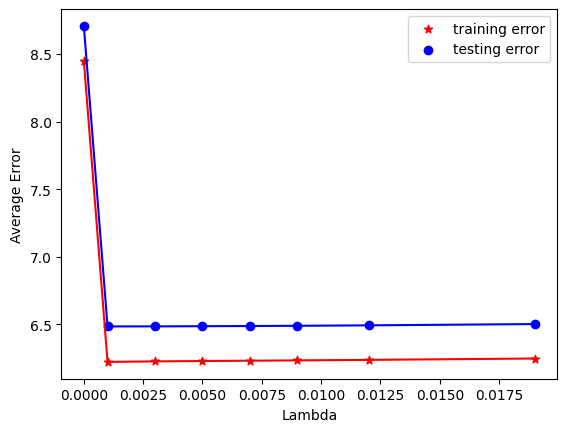

In [18]:
# Lambda Options
lambdaVal = np.array([0.0, 0.001, 0.003, 0.005, 0.007, 0.009, 0.012, 0.019])

# Initialize Data structure matrix for errors
num_iters = 20
num_lambdas = len(lambdaVal)
ErrTrain = np.zeros((num_iters, num_lambdas))
ErrTest  = np.zeros((num_iters, num_lambdas))

# Train iter = 20 models
for iter in range(20):
    # Seed Random Generator
    np.random.seed(int(D + iter))
    randArr = np.random.permutation(numSamples)

    # Split 85% and 15%
    cutidx = int(numSamples * 0.85)
    randArrTrain = randArr[0:cutidx]
    randArrTest = randArr[cutidx:numSamples]
    X_train = X[randArrTrain, :]                # Take only first 90 samples of random index
    X_test = X[randArrTest, :]                  # Take only last 10 samples of random index
    y_train = y[randArrTrain]
    y_test = y[randArrTest]

    # Train Model for each lambda (store in vector)
    # Vectorizing not worth confusion for only 8 values
    for i in range(num_lambdas):
        currLam = lambdaVal[i]
        theta = Reg_normalEqn(X_train, y_train, currLam)

        # Training MSE
        hypTrain = X_train @ theta                      # Compute trained y expected
        errorSq = (hypTrain - y_train) ** 2             # Find Error for ith lambda for all samples
        J = np.mean(errorSq)
        ErrTrain[iter, i] = J                           # Store Errors for given iteration

        # Testing MSE
        hypTest = X_test @ theta                        # Compute trained y expected
        errorSq = (hypTest - y_test) ** 2               # Find Error for ith lambda for all samples
        J = np.mean(errorSq)
        ErrTest[iter, i] = J                            # Store errors for given iteration

# Compute average MSE
ErrAvgTrain = np.mean(ErrTrain, axis=0)                 # Compute mean along rows (dim = 0)
ErrAvgTest = np.mean(ErrTest, axis=0)

# Plot for fitting visualization
plt.plot(lambdaVal, ErrAvgTrain, color="red")
plt.scatter(lambdaVal, ErrAvgTrain, marker="*", color="red", label="training error")
plt.plot(lambdaVal, ErrAvgTest, color="blue")
plt.scatter(lambdaVal, ErrAvgTest, marker="o", color="blue", label="testing error")
#plt.xlim(0, 0.02)
#plt.ylim(3.11, 3.18)
plt.xlabel("Lambda")
plt.ylabel("Average Error")
plt.legend(loc="upper right")



**Text Response:**  
1. While this figure output is clearly incorrect since the training and testing error move together,  
the lowest testing average is when lambda = 0.001  
2. As lambda increases, the training error increases always. Since the model was trained on this data,  
overfitting will result in the lowest error and as lambda increases, the weights decrease and eventually  
becomes underfit
3. Testing error starts very high, decreases, and finally increases again steadily.  
This behavior is explained by a small lambda and large error indicating an overfit to the training set.  
The model then becomes properly generalized as theta increases and will increase steadily as the model  
becomes underfit.  
4. I would reccomend lambda = 0.001 since it has the smallest testing error.   
